In [1]:
pip install requests matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


### Script di ricerca (Geocoding)

In [ ]:
import pandas as pd
import requests as rq # gestire api

# Chiediamo all'utente di inserire la città da ricercare
citta_da_cercare = input("Inserisci il nome della città da ricercare: ")

# Configurazione dell'endpoint di GeoCoding
url_api_geocoding = "https://geocoding-api.open-meteo.com/v1/search"

parametri = {
    "name": citta_da_cercare,
    "count": "10", # Mostra un numero massimo di 10 risultati
    "language": "it" # Nome dei paesi in italiano
}

# Richiesta all'api
risposta = rq.get(url_api_geocoding, params=parametri)

dati = risposta.json()

# |Verifica se l' API ha trovato|
# Trasformiamo la lista dei risultati in un dataframe usando pandas
if "results" in dati:
    df_citta = pd.DataFrame(dati["results"])

    info_utili = ["name", "country", "admin1", "latitude", "longitude", "timezone"]

    colonne = [col for col in info_utili if col in df_citta.columns]

    df_pulito = df_citta[colonne]

    rinomina = {
        "name": "Città",
        "country": "Nazione",
        "admin1": "Regione/Stato",
        "latitude": "Latitudine",
        "longitude": "Longitudine",
        "timezone": "Fuso Orario",
    }

    df_pulito = df_pulito.rename(columns= rinomina)

    print(f"\n Ecco i risultati di {citta_da_cercare}")
    print(df_pulito.to_string())

else:
    print(f"Nessun risultato trovato per {citta_da_cercare}")



 Ecco i risultati di Milano
       Città      Nazione            Regione/Stato  Latitudine  Longitudine         Fuso Orario
0     Milano       Italia                Lombardia    45.46427      9.18951         Europe/Rome
1     Milano  Stati Uniti                    Texas    30.71047    -96.86331     America/Chicago
2     Milano         Perù                  Huánuco    -8.74567    -76.15826        America/Lima
3     Milano       Spagna         Castiglia e León    41.09237     -6.59932       Europe/Madrid
4     Milano       Italia                   Umbria    42.78235     12.59836         Europe/Rome
5     Milano    Indonesia   Sumatra Settentrionale     2.21667     99.83333        Asia/Jakarta
6     Milano     Colombia     dipartimento di Meta     3.93333    -72.75000      America/Bogota
7     Milano   Costa Rica       Provincia di Limón    10.18982    -83.57674  America/Costa_Rica
8    Milanów      Polonia     voivodato di Lublino    51.70374     22.88830       Europe/Warsaw
9  Milanówe

# ESERCIZIO: usare API sugli esercizi fatti nei giorni scorsi (per Lunedi)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd # Per i DataFrame
import requests as rq # Per gestire API

url = 'https://api.open-meteo.com/v1/forecast'

parametri = {
    "latitude": 40.32162,
    "longitude": 15.0537,
    "hourly": "temperature_2m",
    "timezone": "Europe/Rome"
}

# Facciamo la chiamata HTTP Get all'API
risposta = rq.get(url, params=parametri)

dati_json = risposta.json()

dati_meteo = {
    'Data_ora': pd.to_datetime(dati_json['hourly']['time']),
    'Temperatura °C': dati_json['hourly']['temperature_2m']
}

df = pd.DataFrame(dati_meteo)

print("Prime righe che mostra l\'API:  ")
df

Prime righe che mostra l'API:  


,Data_ora,Temperatura °C
0,2026-05-22 00:00:00,15.3
1,2026-05-22 01:00:00,15.5
2,2026-05-22 02:00:00,14.9
3,2026-05-22 03:00:00,14.7
4,2026-05-22 04:00:00,14.7
...,...,...
163,2026-05-28 19:00:00,22.5
164,2026-05-28 20:00:00,21.6
165,2026-05-28 21:00:00,20.3
166,2026-05-28 22:00:00,18.8


# Calcolo Statistiche

In [ ]:
print('\n------- Statistiche Veloci --------')
print(f"Temperatura Massima prevista: {df['Temperatura °C'].max()} °C")
print(f"Temperatura Minima prevista: {df['Temperatura °C'].min()} °C")
print(f"Temperatura Media prevista: {df['Temperatura °C'].mean():.2f} °C")


------- Statistiche Veloci --------
Temperatura Massima prevista: 28.2 °C
Temperatura Minima prevista: 13.6 °C
Temperatura Media prevista: 20.32 °C


# Creazione del grafico PLOT

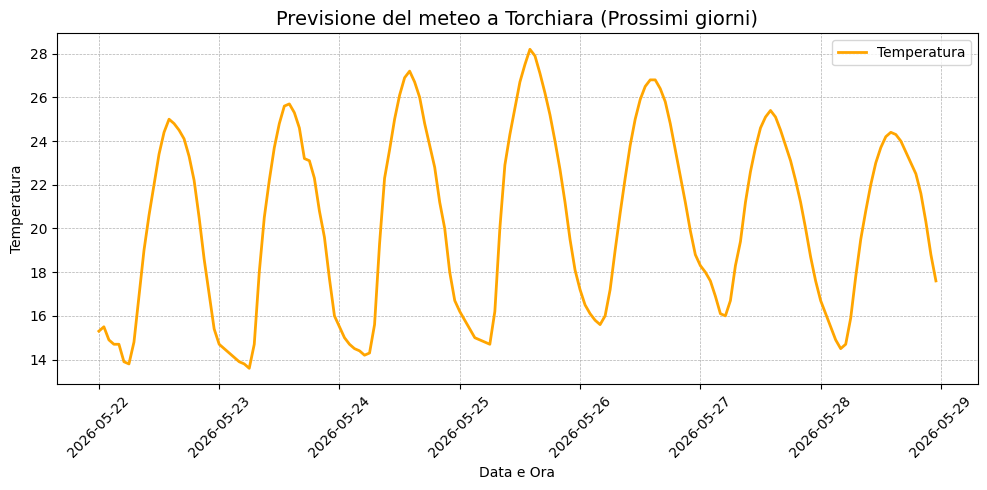

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Data_ora'], df['Temperatura °C'], color = 'orange', label = "Temperatura", linewidth = 2)
plt.title(f"Previsione del meteo a Torchiara (Prossimi giorni)", fontsize=14)
plt.xlabel('Data e Ora', fontsize=10)
plt.ylabel('Temperatura', fontsize = 10)
plt.grid(True, linestyle = '--', linewidth = 0.5)

plt.xticks(rotation = 45)
plt.tight_layout()
plt.legend()

plt.show()